# Counting Principles

Counting is one of the most fundamental concepts in mathematics and computer science. Whether we are calculating probabilities, analyzing algorithms, or solving combinatorial problems, we need systematic ways to count.

In this notebook, we explore the two foundational rules of counting:

1. **Product Rule** (Multiplication Principle)
2. **Sum Rule** (Addition Principle)

We will also see how **double counting** can lead to errors, which motivates the need for more careful techniques like **permutations** and **combinations** (covered in upcoming notebooks).

In [1]:
from itertools import product, chain
import math
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
from libs.venn import venn

print("Libraries imported successfully!")

Libraries imported successfully!


---
## 1. Product Rule of Counting (Multiplication Principle)

### Statement

If a task can be broken down into a **sequence of steps**, where:
- Step 1 can be done in $n_1$ ways,
- Step 2 can be done in $n_2$ ways,
- ...
- Step $k$ can be done in $n_k$ ways,

and **each step is independent** of the others, then the total number of ways to complete the entire task is:

$$n_1 \times n_2 \times \cdots \times n_k$$

### Key Condition
The product rule applies when we need to perform **ALL** steps (i.e., step 1 **AND** step 2 **AND** ... step $k$).

### Example 1: Outfit Combinations

You have **3 shirts** (Red, Blue, Green) and **2 pants** (Black, White).

How many different outfits can you make?

- Step 1: Choose a shirt → 3 ways
- Step 2: Choose pants → 2 ways

**Total outfits** = $3 \times 2 = 6$

Every shirt pairs with every pair of pants — the product rule fills a grid:

<table>
<tr>
  <th></th>
  <th>Black pants</th>
  <th>White pants</th>
</tr>
<tr>
  <td><b>Red shirt</b></td>
  <td><pre style="margin:0">Red + Black</pre></td>
  <td><pre style="margin:0">Red + White</pre></td>
</tr>
<tr>
  <td><b>Blue shirt</b></td>
  <td><pre style="margin:0">Blue + Black</pre></td>
  <td><pre style="margin:0">Blue + White</pre></td>
</tr>
<tr>
  <td><b>Green shirt</b></td>
  <td><pre style="margin:0">Green + Black</pre></td>
  <td><pre style="margin:0">Green + White</pre></td>
</tr>
</table>

<br>

> **Visual rule**: Product rule = area of a grid. Rows × Columns = Total cells.

In [184]:
shirts = ["Red", "Blue", "Green"]
pants = ["Black", "White"]

outfits = list(product(shirts, pants))

print(f"Number of outfits: {len(outfits)}")
print(f"Product Rule: {len(shirts)} × {len(pants)} = {len(shirts) * len(pants)}")
print()
for i, (s, p) in enumerate(outfits, 1):
    print(f"  Outfit {i}: {s} shirt + {p} pants")

Number of outfits: 6
Product Rule: 3 × 2 = 6

  Outfit 1: Red shirt + Black pants
  Outfit 2: Red shirt + White pants
  Outfit 3: Blue shirt + Black pants
  Outfit 4: Blue shirt + White pants
  Outfit 5: Green shirt + Black pants
  Outfit 6: Green shirt + White pants


### Example 2: License Plates

A license plate consists of **2 letters** followed by **3 digits**.

- Letters: A-Z (26 choices each)
- Digits: 0-9 (10 choices each)

Each position is an independent step — fill in one slot at a time:

<table>
<tr>
  <th></th>
  <th>Slot 1</th>
  <th></th>
  <th>Slot 2</th>
  <th></th>
  <th>Slot 3</th>
  <th></th>
  <th>Slot 4</th>
  <th></th>
  <th>Slot 5</th>
</tr>
<tr>
  <td><b>Type</b></td>
  <td>Letter</td>
  <td></td>
  <td>Letter</td>
  <td></td>
  <td>Digit</td>
  <td></td>
  <td>Digit</td>
  <td></td>
  <td>Digit</td>
</tr>
<tr>
  <td><b>Choices</b></td>
  <td><b>26</b></td>
  <td>×</td>
  <td><b>26</b></td>
  <td>×</td>
  <td><b>10</b></td>
  <td>×</td>
  <td><b>10</b></td>
  <td>×</td>
  <td><b>10</b></td>
</tr>
<tr>
  <td><b>Sample</b></td>
  <td><pre style="margin:0">A..Z</pre></td>
  <td></td>
  <td><pre style="margin:0">A..Z</pre></td>
  <td></td>
  <td><pre style="margin:0">0..9</pre></td>
  <td></td>
  <td><pre style="margin:0">0..9</pre></td>
  <td></td>
  <td><pre style="margin:0">0..9</pre></td>
</tr>
</table>

<br>

$$26 \times 26 \times 10 \times 10 \times 10 = 676{,}000$$

In [185]:
letters = 26  # A-Z
digits = 10   # 0-9

# 2 letters followed by 3 digits
total_plates = letters * letters * digits * digits * digits

print(f"Total license plates: {letters} × {letters} × {digits} × {digits} × {digits} = {total_plates:,}")

Total license plates: 26 × 26 × 10 × 10 × 10 = 676,000


### Example 3: PIN Codes

A 4-digit PIN code where each digit is 0-9.

<pre style="margin:0">
With repetition:
┌────┐  ┌────┐  ┌────┐  ┌────┐
│ 10 │  │ 10 │  │ 10 │  │ 10 │  →  10 × 10 × 10 × 10 = 10,000
└────┘  └────┘  └────┘  └────┘

Without repetition:
┌────┐  ┌────┐  ┌────┐  ┌────┐
│ 10 │  │  9 │  │  8 │  │  7 │  →  10 ×  9 ×  8 ×  7 =  5,040
└────┘  └────┘  └────┘  └────┘
          ↑        ↑        ↑
       used 1   used 2   used 3
</pre>

Notice: when repetition is **not allowed**, the choices at each step **decrease** — the steps are no longer fully independent. This is where the product rule starts connecting to **permutations**.

In [186]:
# With repetition
with_rep = 10 * 10 * 10 * 10
print(f"4-digit PINs (repetition allowed):     10 × 10 × 10 × 10 = {with_rep:,}")

# Without repetition
without_rep = 10 * 9 * 8 * 7
print(f"4-digit PINs (no repetition):           10 ×  9 ×  8 ×  7 = {without_rep:,}")

print()
print(f"Difference: {with_rep - without_rep:,} fewer PINs when digits can't repeat")

4-digit PINs (repetition allowed):     10 × 10 × 10 × 10 = 10,000
4-digit PINs (no repetition):           10 ×  9 ×  8 ×  7 = 5,040

Difference: 4,960 fewer PINs when digits can't repeat


### Example 4: Counting Digital Images

Consider a digital image where each **pixel** can display one of $2^{24} \approx 17$ million colors (True Color).

Building an image is a multi-step process — choose a color for each pixel, one at a time. By the product rule:

$$\text{Number of images} = (\text{colors per pixel})^{\text{number of pixels}} = (2^{24})^n \approx (17{,}000{,}000)^n$$

| Image size | Pixels ($n$) | Possible images | vs. atoms in universe ($\approx 10^{80}$) |
|:---:|:---:|:---:|---|
| Tiny grid | 12 | $(17\text{M})^{12} \approx 10^{86}$ | **A million× more** than atoms |
| Small grid | 300 | $(17\text{M})^{300} \approx 10^{2167}$ | Incomprehensibly larger |
| Phone camera | 12,000,000 | $(17\text{M})^{12\text{M}} \approx 10^{86{,}696{,}638}$ | Absurd |

> **CS takeaway**: Even a 12-pixel image has more possible states than there are atoms in the observable universe. This is why brute-force search over image spaces is impossible, and why techniques like neural networks are needed for tasks like image generation.

In [187]:
colors_per_pixel = 2 ** 24

print(f"Colors per pixel (True Color): 2^24 = {colors_per_pixel:,}")
print()
print(f"{'Image':>14}   {'Pixels':>12}   {'log10(images)':>16}   {'vs 10^80 (atoms)'}")
print("-" * 72)

for label, pixels in [("Tiny grid", 12), ("Small grid", 300), ("Phone 12MP", 12_000_000)]:
    log10_images = pixels * math.log10(colors_per_pixel)
    ratio = f"10^{log10_images - 80:,.0f} × more" if log10_images > 80 else "fewer"
    print(f"{label:>14}   {pixels:>12,}   10^{log10_images:>13,.0f}   {ratio}")

Colors per pixel (True Color): 2^24 = 16,777,216

         Image         Pixels      log10(images)   vs 10^80 (atoms)
------------------------------------------------------------------------
     Tiny grid             12   10^           87   10^7 × more
    Small grid            300   10^        2,167   10^2,087 × more
    Phone 12MP     12,000,000   10^   86,696,639   10^86,696,559 × more


### Example 5: Game State Space — Go Board

A [Go](https://en.wikipedia.org/wiki/Go_(game)) board has $19 \times 19 = 361$ intersection points. Each point can be in one of **3 states**: Black stone, White stone, or Empty.

Here is a small $3 \times 3$ section — each point has 3 independent choices:

<pre style="margin:0">
┌───┬───┬───┐
│ ● │ ○ │ · │   ● = Black
├───┼───┼───┤
│ · │ ● │ · │   ○ = White
├───┼───┼───┤
│ ○ │ · │ ● │   · = Empty
└───┴───┴───┘
Even this 3×3 grid: 3⁹ = 19,683 configurations
</pre>

By the product rule (one step per point, 3 choices per step):

$$3^{361} \approx 10^{172}$$

That is roughly the **square** of the number of atoms in the observable universe ($\approx 10^{80}$). If every atom in the universe contained *another* universe of atoms, only then would there be as many atoms as there are Go board configurations.

> **CS takeaway**: No computer can store more states than atoms in the universe. This is why Go programs use techniques like Monte Carlo Tree Search rather than exhaustive enumeration — the state space is simply too large.

In [188]:
points = 19 * 19
states_per_point = 3

log10_go = points * math.log10(states_per_point)

print(f"Go board: {19} × {19} = {points} points")
print(f"States per point: {states_per_point} (Black, White, Empty)")
print(f"Total configurations: {states_per_point}^{points} ≈ 10^{log10_go:.0f}")
print()
print(f"Atoms in observable universe ≈ 10^80")
print(f"Go states / atoms ≈ 10^{log10_go - 80:.0f}")
print(f"That is (10^80)^2 ≈ 10^160 — roughly the square of the atom count!")

Go board: 19 × 19 = 361 points
States per point: 3 (Black, White, Empty)
Total configurations: 3^361 ≈ 10^172

Atoms in observable universe ≈ 10^80
Go states / atoms ≈ 10^92
That is (10^80)^2 ≈ 10^160 — roughly the square of the atom count!


### Example 6: The Product Rule in Reverse — Synthetic Data

The product rule also works **backwards**. If $k$ binary (yes/no) decisions produce $2^k$ unique outcomes, how many decisions do we need to generate at least $N$ unique data points?

$$2^k \geq N \implies k \geq \lceil \log_2 N \rceil$$

Each binary decision **doubles** the number of outcomes:

<pre style="margin:0">
Decisions:   1     2      3       4        5    ...    24
             ↓     ↓      ↓       ↓        ↓           ↓
Outcomes:    2     4      8      16       32    ...  16,777,216
              ×2    ×2     ×2      ×2
</pre>

For example, to synthetically generate **10 million** unique data points:

$$\lceil \log_2 10{,}000{,}000 \rceil = 24$$

Just **24 binary decisions** are enough! This is why binary search runs in $O(\log n)$ time, and why decision trees with modest depth can classify millions of items.

> **CS takeaway**: The product rule creates exponential growth — and taking its inverse gives **logarithmic** scaling. This is the foundation of efficient algorithms like binary search, balanced trees, and hash tables.

In [189]:
target = 10_000_000

k = math.ceil(math.log2(target))
outcomes = 2 ** k

print(f"Target: {target:,} unique data points")
print(f"Binary decisions needed: ceil(log2({target:,})) = {k}")
print(f"Actual outcomes from {k} binary decisions: 2^{k} = {outcomes:,}")
print()
print(f"{'Decisions (k)':>14}   {'Unique outcomes (2^k)':>22}")
print("-" * 40)
for d in [5, 10, 15, 20, 24, 30]:
    print(f"{d:>14}   {2**d:>22,}")

Target: 10,000,000 unique data points
Binary decisions needed: ceil(log2(10,000,000)) = 24
Actual outcomes from 24 binary decisions: 2^24 = 16,777,216

 Decisions (k)    Unique outcomes (2^k)
----------------------------------------
             5                       32
            10                    1,024
            15                   32,768
            20                1,048,576
            24               16,777,216
            30            1,073,741,824


---
## 2. Sum Rule of Counting (Addition Principle)

### Statement

If a task can be done **either** by method A **or** method B, and:
- Method A can be done in $n_A$ ways,
- Method B can be done in $n_B$ ways,
- **Methods A and B have no overlap** (they are mutually exclusive),

then the total number of ways to do the task is:

$$n_A + n_B$$

More generally, for $k$ mutually exclusive methods:

$$n_1 + n_2 + \cdots + n_k$$

### Key Condition
The sum rule applies when we choose **ONE** option from different **non-overlapping** categories (method A **OR** method B).

### Example 7: Choosing a Pet

A pet store has **5 dogs**, **3 cats**, and **4 birds**.

If you want to adopt **one** pet, how many choices do you have?

- You choose a dog **OR** a cat **OR** a bird
- These categories don't overlap (a dog is not a cat)

<pre style="margin:0">
        ┌───────────────────────────────────────┐
        │           Pet Store (12)              │
        └───────────────────────────────────────┘
               /           |           \
        ┌──────────┐ ┌──────────┐ ┌──────────┐
        │  Dogs    │ │  Cats    │ │  Birds   │
        │   (5)    │ │   (3)    │ │   (4)    │
        └──────────┘ └──────────┘ └──────────┘
              OR           OR
        ─────────────────────────────────────────
                  5  +  3  +  4  =  12
</pre>

> **Visual rule**: Sum rule = separate, non-overlapping groups. Count each group and add.

In [190]:
dogs = ["Buddy", "Max", "Bella", "Charlie", "Luna"]
cats = ["Whiskers", "Mittens", "Shadow"]
birds = ["Tweety", "Rio", "Kiwi", "Sky"]

# Sum rule: choose ONE pet from any category
all_pets = list(chain(dogs, cats, birds))

print(f"Dogs: {len(dogs)}, Cats: {len(cats)}, Birds: {len(birds)}")
print(f"Sum Rule: {len(dogs)} + {len(cats)} + {len(birds)} = {len(all_pets)}")
print()
print(f"All choices: {all_pets}")

Dogs: 5, Cats: 3, Birds: 4
Sum Rule: 5 + 3 + 4 = 12

All choices: ['Buddy', 'Max', 'Bella', 'Charlie', 'Luna', 'Whiskers', 'Mittens', 'Shadow', 'Tweety', 'Rio', 'Kiwi', 'Sky']


### Example 8: Choosing a Course

A student can take either a **math** elective or a **science** elective (but not both).

- Math electives available: Algebra, Calculus, Statistics → 3 choices
- Science electives available: Physics, Chemistry, Biology, Astronomy → 4 choices

**Total choices** = $3 + 4 = 7$

In [191]:
math_courses = ["Algebra", "Calculus", "Statistics"]
science_courses = ["Physics", "Chemistry", "Biology", "Astronomy"]

total = len(math_courses) + len(science_courses)
print(f"Math electives: {len(math_courses)}")
print(f"Science electives: {len(science_courses)}")
print(f"Total choices (Sum Rule): {len(math_courses)} + {len(science_courses)} = {total}")

Math electives: 3
Science electives: 4
Total choices (Sum Rule): 3 + 4 = 7


---
## 3. Combining Product and Sum Rules

Real problems often require **both** rules. The key is to identify:
- **AND** → multiply (product rule)
- **OR** → add (sum rule)

### Example 9: Meal Combos

A restaurant offers two types of meals:
- **Vegetarian meal**: Choose 1 of 3 appetizers AND 1 of 4 mains → $3 \times 4 = 12$ combos
- **Non-vegetarian meal**: Choose 1 of 2 appetizers AND 1 of 5 mains → $2 \times 5 = 10$ combos

Total meals = Vegetarian combos **OR** Non-vegetarian combos = $12 + 10 = 22$

<table>
<tr>
  <td style="border:2px solid green; padding:12px; vertical-align:top">
    <b>Vegetarian</b> (Product Rule: AND)<br><br>
    <table>
    <tr>
      <th></th><th>Pasta</th><th>Risotto</th><th>Stir-fry</th><th>Curry</th>
    </tr>
    <tr>
      <td><b>Soup</b></td><td>✓</td><td>✓</td><td>✓</td><td>✓</td>
    </tr>
    <tr>
      <td><b>Salad</b></td><td>✓</td><td>✓</td><td>✓</td><td>✓</td>
    </tr>
    <tr>
      <td><b>Bruschetta</b></td><td>✓</td><td>✓</td><td>✓</td><td>✓</td>
    </tr>
    </table>
    <pre style="margin:4px 0 0 0">3 appetizers × 4 mains = 12</pre>
  </td>
  <td style="text-align:center; vertical-align:middle; border:none; font-size:1.3em"><b>+</b><br>(OR)</td>
  <td style="border:2px solid brown; padding:12px; vertical-align:top">
    <b>Non-vegetarian</b> (Product Rule: AND)<br><br>
    <table>
    <tr>
      <th></th><th>Steak</th><th>Salmon</th><th>Chicken</th><th>Lamb</th><th>Duck</th>
    </tr>
    <tr>
      <td><b>Wings</b></td><td>✓</td><td>✓</td><td>✓</td><td>✓</td><td>✓</td>
    </tr>
    <tr>
      <td><b>Shrimp</b></td><td>✓</td><td>✓</td><td>✓</td><td>✓</td><td>✓</td>
    </tr>
    </table>
    <pre style="margin:4px 0 0 0">2 appetizers × 5 mains = 10</pre>
  </td>
</tr>
<tr>
  <td colspan="3" style="text-align:center; border:none; font-size:1.1em"><b>= 12 + 10 = 22 total meal combos</b></td>
</tr>
</table>

<br>

> **Pattern**: Use the **product rule** within each card (AND — grid area), then the **sum rule** across cards (OR — add totals).

In [192]:
# Vegetarian options
veg_appetizers = ["Soup", "Salad", "Bruschetta"]
veg_mains = ["Pasta", "Risotto", "Stir-fry", "Curry"]

# Non-vegetarian options
nonveg_appetizers = ["Wings", "Shrimp"]
nonveg_mains = ["Steak", "Salmon", "Chicken", "Lamb", "Duck"]

# Product rule within each category
veg_combos = list(product(veg_appetizers, veg_mains))
nonveg_combos = list(product(nonveg_appetizers, nonveg_mains))

# Sum rule across categories
total_meals = len(veg_combos) + len(nonveg_combos)

print(f"Vegetarian combos (Product Rule):     {len(veg_appetizers)} × {len(veg_mains)} = {len(veg_combos)}")
print(f"Non-veg combos (Product Rule):        {len(nonveg_appetizers)} × {len(nonveg_mains)} = {len(nonveg_combos)}")
print(f"Total meal options (Sum Rule):        {len(veg_combos)} + {len(nonveg_combos)} = {total_meals}")

Vegetarian combos (Product Rule):     3 × 4 = 12
Non-veg combos (Product Rule):        2 × 5 = 10
Total meal options (Sum Rule):        12 + 10 = 22


---
## 4. The Double Counting Problem

The sum rule requires that categories **do not overlap**. When categories **do overlap**, naively adding them leads to **double counting** — some items get counted more than once.

### Inclusion-Exclusion Principle

For **two overlapping** sets $A$ and $B$:

$$|A \cup B| = |A| + |B| - |A \cap B|$$

We **subtract** the overlap because those elements were counted once in $|A|$ and once in $|B|$ — hence counted **twice**.

For **three sets**:

$$|A \cup B \cup C| = |A| + |B| + |C| - |A \cap B| - |A \cap C| - |B \cap C| + |A \cap B \cap C|$$

### Example 10: Double Counting in Action

In a class of students:
- **12** students play **football**
- **10** students play **cricket**
- **4** students play **both**

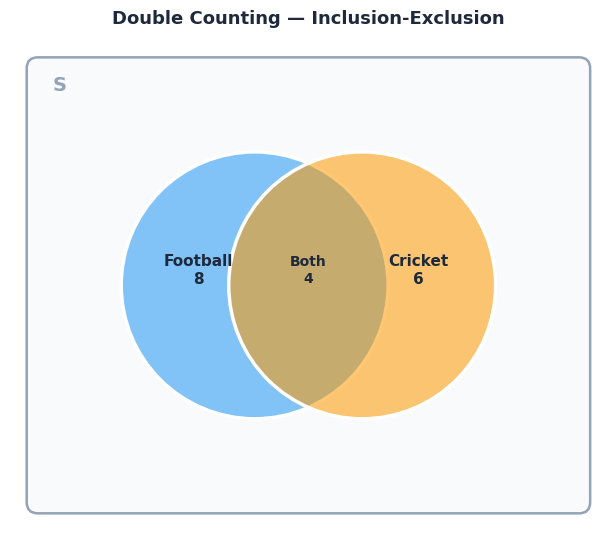

Naive sum: 12 + 10 = 22  (4 counted twice!)
Correct:   12 + 10 − 4 = 18  ✓


In [2]:
football_only = 8
cricket_only = 6
both = 4

venn(f'''
venn-beta
  title "Double Counting — Inclusion-Exclusion"
  set F["Football<br/>{football_only}"]
  set C["Cricket<br/>{cricket_only}"]
  union F,C["Both<br/>{both}"]
  style F fill:#2196F3
  style C fill:#FF9800
''')

naive = 12 + 10
correct = 12 + 10 - 4
print(f"Naive sum: 12 + 10 = {naive}  (4 counted twice!)")
print(f"Correct:   12 + 10 − 4 = {correct}  ✓")

In [194]:
football = set(range(1, 13))       # Students 1-12 play football
cricket = set(range(9, 19))        # Students 9-18 play cricket
# Overlap: students 9, 10, 11, 12 play both

both = football & cricket
either = football | cricket

print(f"Football players:          {len(football)}")
print(f"Cricket players:           {len(cricket)}")
print(f"Play both:                 {len(both)} → {both}")
print()
print(f"WRONG (naive sum):         {len(football)} + {len(cricket)} = {len(football) + len(cricket)}")
print(f"CORRECT (inclusion-excl):  {len(football)} + {len(cricket)} - {len(both)} = {len(either)}")
print(f"Verified with set union:   {len(either)}")

Football players:          12
Cricket players:           10
Play both:                 4 → {9, 10, 11, 12}

WRONG (naive sum):         12 + 10 = 22
CORRECT (inclusion-excl):  12 + 10 - 4 = 18
Verified with set union:   18


### Example 11: Counting Integers Divisible by 2 or 3

How many integers from 1 to 100 are divisible by **2 or 3**?

- Divisible by 2: $\lfloor 100/2 \rfloor = 50$
- Divisible by 3: $\lfloor 100/3 \rfloor = 33$
- Divisible by **both** 2 and 3 (i.e., by 6): $\lfloor 100/6 \rfloor = 16$

**Naive sum**: $50 + 33 = 83$ ← **Wrong!** (double counts multiples of 6)

**Inclusion-Exclusion**: $50 + 33 - 16 = 67$ ✓

In [195]:
N = 100

div_by_2 = {x for x in range(1, N + 1) if x % 2 == 0}
div_by_3 = {x for x in range(1, N + 1) if x % 3 == 0}
div_by_both = div_by_2 & div_by_3  # divisible by 6
div_by_2_or_3 = div_by_2 | div_by_3

print(f"Divisible by 2:            {len(div_by_2)}")
print(f"Divisible by 3:            {len(div_by_3)}")
print(f"Divisible by both (6):     {len(div_by_both)}")
print()
print(f"WRONG (naive sum):         {len(div_by_2)} + {len(div_by_3)} = {len(div_by_2) + len(div_by_3)}")
print(f"CORRECT (inclusion-excl):  {len(div_by_2)} + {len(div_by_3)} - {len(div_by_both)} = {len(div_by_2_or_3)}")

Divisible by 2:            50
Divisible by 3:            33
Divisible by both (6):     16

WRONG (naive sum):         50 + 33 = 83
CORRECT (inclusion-excl):  50 + 33 - 16 = 67


### Example 12: Valid Bit Strings (Inclusion-Exclusion)

An **8-bit string** is sent over a network. The receiver accepts strings that:
- **Start with** `01`, **or**
- **End with** `10`

How many valid strings are there?

<table>
<tr>
  <th>Set</th>
  <th>Bit positions ([ ] = free, [0]/[1] = fixed)</th>
  <th>Count</th>
</tr>
<tr>
  <td><b>A</b> starts with 01</td>
  <td><pre style="margin:0">[0] [1] [ ] [ ] [ ] [ ] [ ] [ ]
fix fix  ·   ·   ·   ·   ·   ·</pre></td>
  <td>$2^6 = 64$</td>
</tr>
<tr>
  <td><b>B</b> ends with 10</td>
  <td><pre style="margin:0">[ ] [ ] [ ] [ ] [ ] [ ] [1] [0]
 ·   ·   ·   ·   ·   · fix fix</pre></td>
  <td>$2^6 = 64$</td>
</tr>
<tr>
  <td><b>A ∩ B</b> both</td>
  <td><pre style="margin:0">[0] [1] [ ] [ ] [ ] [ ] [1] [0]
fix fix  ·   ·   ·   · fix fix</pre></td>
  <td>$2^4 = 16$</td>
</tr>
</table>

<br><br>

$$|A \cup B| = 64 + 64 - 16 = 112$$

In [196]:
# 8-bit strings: accepted if starts with "01" OR ends with "10"
bits = 8

starts_01 = 2 ** (bits - 2)       # first 2 bits fixed
ends_10   = 2 ** (bits - 2)       # last 2 bits fixed
both      = 2 ** (bits - 4)       # first 2 and last 2 fixed

valid = starts_01 + ends_10 - both

print(f"8-bit strings that start with '01':             2^{bits-2} = {starts_01}")
print(f"8-bit strings that end with '10':               2^{bits-2} = {ends_10}")
print(f"8-bit strings that start with '01' AND end with '10': 2^{bits-4} = {both}")
print()
print(f"Inclusion-Exclusion: {starts_01} + {ends_10} - {both} = {valid}")
print()

# Brute force verification
count = 0
for i in range(2 ** bits):
    s = format(i, f'0{bits}b')
    if s[:2] == '01' or s[-2:] == '10':
        count += 1

print(f"Brute force: {count}")
print(f"Match: {'✓' if count == valid else '✗'}")

8-bit strings that start with '01':             2^6 = 64
8-bit strings that end with '10':               2^6 = 64
8-bit strings that start with '01' AND end with '10': 2^4 = 16

Inclusion-Exclusion: 64 + 64 - 16 = 112

Brute force: 112
Match: ✓


### Why Double Counting Matters

Double counting is not just an edge case — it shows up everywhere:

| Scenario | What gets double-counted |
|----------|-------------------------|
| Counting passwords with at least one digit OR one special char | Passwords that have both |
| Counting students in club A or club B | Students in both clubs |
| Counting paths through a network | Paths that share edges |
| Probability of event A or event B | Outcomes in both events |

When problems involve **selecting items from a set** — especially without ordering or with constraints — simple product/sum rules become error-prone. This is exactly where **permutations** and **combinations** provide systematic, reliable formulas.

---
## 5. Practice Problems

Try solving these on your own before running the solution cells!

### Problem 1: Phone Numbers

A phone number has **10 digits**. The first digit cannot be 0.

How many valid phone numbers are there?

<pre style="margin:0">
Phone: [1-9] [0-9] [0-9] [0-9] [0-9] [0-9] [0-9] [0-9] [0-9] [0-9]
        ↑     ↑     ↑     ↑     ↑     ↑     ↑     ↑     ↑     ↑
        9  ×  10  × 10  × 10  × 10  × 10  × 10  × 10  × 10  × 10
      
      = 9 × 10⁹ = 9,000,000,000
</pre>

In [197]:
# SOLUTION
# First digit: 1-9 → 9 choices
# Remaining 9 digits: 0-9 → 10 choices each
# Product Rule: 9 × 10^9

first_digit = 9
other_digit = 10
number_of_other_digits = 10 - 9
total_phone_numbers = first_digit * (other_digit ** number_of_other_digits)
print(f"Valid phone numbers: 9 × 10⁹ = {total_phone_numbers:,}")

Valid phone numbers: 9 × 10⁹ = 90


### Problem 2: Committee Selection

A committee needs **one representative** from either:
- The **math department** (8 professors), OR
- The **physics department** (6 professors), OR
- The **CS department** (10 professors)

No professor belongs to two departments. How many ways can a representative be chosen?

<pre style="margin:0">
         Math (8)        Physics (6)       CS (10)
      ┌──────────┐    ┌──────────┐    ┌──────────┐
      │ Prof 1   │    │ Prof 1   │    │ Prof 1   │
      │ Prof 2   │    │ Prof 2   │    │ Prof 2   │
      │  ...     │ OR │  ...     │ OR │  ...     │
      │ Prof 8   │    │ Prof 6   │    │ Prof10   │
      └──────────┘    └──────────┘    └──────────┘
            ↓               ↓               ↓
            8  +            6  +            10   =  24 choices
</pre>

In [198]:
# SOLUTION
# Sum Rule (mutually exclusive categories)

math_dept = 8
physics_dept = 6
cs_dept = 10

total = math_dept + physics_dept + cs_dept
print(f"Total ways: {math_dept} + {physics_dept} + {cs_dept} = {total}")

Total ways: 8 + 6 + 10 = 24


### Problem 3: Binary Strings

How many **binary strings** of length 8 are there? (Each position is 0 or 1)

How many of those start with **11** and end with **0**?

**Part A: All 8-bit strings**

<pre style="margin:0">
Position: [1]  [2]  [3]  [4]  [5]  [6]  [7]  [8]
Choices:   2  ×  2  ×  2  ×  2  ×  2  ×  2  ×  2  ×  2
                                                      
           = 2⁸ = 256 total 8-bit strings
</pre>

**Part B: Starting with "11" and ending with "0"**

<pre style="margin:0">
Position: [1]  [2]  [3]  [4]  [5]  [6]  [7]  [8]
          [1]  [1]  [·]  [·]  [·]  [·]  [·]  [0]
           ↑    ↑    ↑    ↑    ↑    ↑    ↑    ↑
          fixed fixed free free free free free fixed
           1  ×  1  ×  2  ×  2  ×  2  ×  2  ×  2  ×  1
                                                   
           = 1 × 1 × 2⁵ × 1 = 32 strings
</pre>

In [199]:
# SOLUTION
# Total binary strings of length 8: 2^8
total_binary = 2 ** 8
print(f"Total binary strings of length 8: 2⁸ = {total_binary}")

# Start with '11' (positions 1,2 fixed) and end with '0' (position 8 fixed)
# Free positions: 3, 4, 5, 6, 7 → 5 positions, each 0 or 1
constrained = 1 * 1 * (2 ** 5) * 1  # fixed × fixed × free × fixed
print(f"Starting with '11' and ending with '0': 1 × 1 × 2⁵ × 1 = {constrained}")

Total binary strings of length 8: 2⁸ = 256
Starting with '11' and ending with '0': 1 × 1 × 2⁵ × 1 = 32


### Problem 4: Inclusion-Exclusion

In a survey of 200 people:
- **120** like coffee
- **90** like tea
- **40** like both coffee and tea

How many people like **coffee or tea** (or both)?

How many people like **neither**?

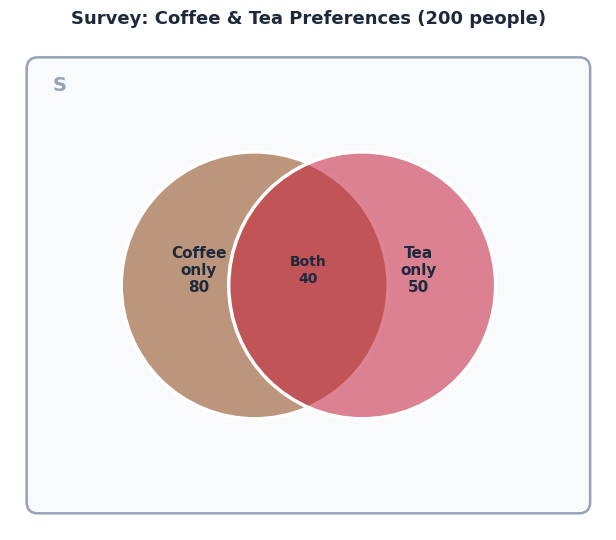

Coffee or Tea: 120 + 90 − 40 = 170 people
Neither:       200 − 170 = 30 people


In [3]:
coffee_only = 120 - 40  # 80
tea_only = 90 - 40      # 50
both = 40

venn(f'''
venn-beta
  title "Survey: Coffee & Tea Preferences (200 people)"
  set C["Coffee<br/>only<br/>{coffee_only}"]
  set T["Tea<br/>only<br/>{tea_only}"]
  union C,T["Both<br/>{both}"]
  style C fill:#8B4513
  style T fill:#C41E3A
''')

print(f"Coffee or Tea: 120 + 90 − 40 = 170 people")
print(f"Neither:       200 − 170 = 30 people")

In [201]:
# SOLUTION
total_people = 200
coffee = 120
tea = 90
both = 40

# Inclusion-Exclusion
coffee_or_tea = coffee + tea - both
neither = total_people - coffee_or_tea

print(f"Like coffee or tea: {coffee} + {tea} - {both} = {coffee_or_tea}")
print(f"Like neither:       {total_people} - {coffee_or_tea} = {neither}")

Like coffee or tea: 120 + 90 - 40 = 170
Like neither:       200 - 170 = 30


### Problem 5: Passwords (Combined Rules)

A password must be **exactly 4 characters long**. Each character is either:
- An uppercase letter (A-Z): 26 choices
- A digit (0-9): 10 choices

**Part A**: How many total passwords are possible?

**Part B**: How many passwords consist of **only letters**?

**Part C**: How many passwords have **at least one digit**?

<pre style="margin:0">
Part A: All 4-character passwords (letters OR digits at each position)
┌──────────┐ ┌──────────┐ ┌──────────┐ ┌──────────┐
│ 26+10=36 │ │ 26+10=36 │ │ 26+10=36 │ │ 26+10=36 │
│          │ │          │ │          │ │          │
│(A-Z,0-9) │ │(A-Z,0-9) │ │(A-Z,0-9) │ │(A-Z,0-9) │
└──────────┘ └──────────┘ └──────────┘ └──────────┘
     ×            ×            ×            ×
                  = 36⁴ = 1,679,616

Part B: Only letters (A-Z at each position)
┌──────────┐ ┌──────────┐ ┌──────────┐ ┌──────────┐
│    26    │ │    26    │ │    26    │ │    26    │
│ (A-Z)    │ │ (A-Z)    │ │ (A-Z)    │ │ (A-Z)    │
└──────────┘ └──────────┘ └──────────┘ └──────────┘
     ×            ×            ×            ×
                  = 26⁴ = 456,976

Part C: At least one digit (complement counting)
  Total - Only letters = 1,679,616 - 456,976 = 1,222,640
</pre>

In [202]:
# SOLUTION
chars_per_position = 26 + 10  # 36 choices per position (letter OR digit)

# Part A: Total passwords (product rule, 4 independent positions)
total_passwords = chars_per_position ** 4
print(f"Part A - Total passwords: 36⁴ = {total_passwords:,}")

# Part B: Only letters
only_letters = 26 ** 4
print(f"Part B - Only letters:    26⁴ = {only_letters:,}")

# Part C: At least one digit = Total - Only letters
# (Complement counting avoids complex double-counting!)
at_least_one_digit = total_passwords - only_letters
print(f"Part C - At least 1 digit: {total_passwords:,} - {only_letters:,} = {at_least_one_digit:,}")
print()
print("Note: Part C uses 'complement counting' — it's much easier to count")
print("what we DON'T want and subtract, rather than directly counting all")
print("cases with 1 digit, 2 digits, 3 digits, or 4 digits separately.")

Part A - Total passwords: 36⁴ = 1,679,616
Part B - Only letters:    26⁴ = 456,976
Part C - At least 1 digit: 1,679,616 - 456,976 = 1,222,640

Note: Part C uses 'complement counting' — it's much easier to count
what we DON'T want and subtract, rather than directly counting all
cases with 1 digit, 2 digits, 3 digits, or 4 digits separately.


---
## 6. Summary

| Rule | When to Use | Formula |
|------|------------|--------|
| **Product Rule** | Task has multiple **sequential, independent** steps (AND) | $n_1 \times n_2 \times \cdots \times n_k$ |
| **Sum Rule** | Task can be done by one of several **mutually exclusive** methods (OR) | $n_1 + n_2 + \cdots + n_k$ |
| **Inclusion-Exclusion** | Categories **overlap** — corrects for double counting | $\lvert A \cup B \rvert = \lvert A \rvert + \lvert B \rvert - \lvert A \cap B \rvert$ |

## 7. What's Next?

The product and sum rules are powerful but run into difficulties when:

1. **Order matters vs. doesn't matter** — Is choosing {A, B} the same as {B, A}? The product rule counts both.
2. **Selecting subsets** — How many ways to pick 3 people from 10? Naive application of the product rule ($10 \times 9 \times 8$) over-counts because it treats different orderings as distinct.
3. **Constraints** — "At least one", "no two adjacent", "exactly $k$" — these require careful decomposition.

These challenges lead us to:

- **Permutations** — counting **ordered** arrangements
- **Combinations** — counting **unordered** selections

The product and sum rules remain the **foundation** — permutations and combinations are built on top of them with systematic corrections for over-counting.